# Taller 2 - Punto 2: Embeddings de Oraciones con Sentence Transformers

Este notebook implementa el procesamiento de documentos PDF y la generación de embeddings de oraciones usando diferentes modelos de Sentence Transformers.

## Objetivos:
1. Carga y procesamiento de documentos PDF
2. Fragmentación (chunking) del texto
3. Generación de embeddings con 4 modelos diferentes
4. Consulta de similitud semántica usando similitud coseno
5. Visualización 2D con PCA para cada modelo

## 2.1 Instalación de Dependencias

In [1]:
import os
import glob
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import warnings
warnings.filterwarnings('ignore')

# Importar funciones del archivo helpers
from helpers import (
    ensure_directories,
    save_experiment_results,
    load_experiment_results,
    save_chunks,
    load_chunks,
    save_embeddings,
    load_embeddings,
    visualize_pca_comparison
)

/home/yenreh/anaconda3/envs/pln_taller2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.2 Carga y Procesamiento de PDFs

Cargamos todos los archivos PDF del directorio especificado usando LangChain.

In [2]:
# Configuracion de directorios
PDF_DIR = "./input/pdfs/"
OUTPUT_DIR = "./output/punto2/"
MODELS_DIR = "./models/punto2/"
RESULTS_DIR = "./results/"
CACHE_DIR = "./input/preprocessed/punto2/"

# Crear directorios necesarios
ensure_directories(2)
os.makedirs(CACHE_DIR, exist_ok=True)

# Control de ejecucion
USAR_CACHE = True
PROCESAR_BAJO_DEMANDA = True
EJECUTAR_TODOS = True

print("Configuracion establecida:")
print(f"- PDF Directory: {PDF_DIR}")
print(f"- Output Directory: {OUTPUT_DIR}")
print(f"- Models Directory: {MODELS_DIR}")
print(f"- Results Directory: {RESULTS_DIR}")
print(f"- Cache Directory: {CACHE_DIR}")
print(f"- Usar cache: {USAR_CACHE}")
print(f"- Procesar bajo demanda: {PROCESAR_BAJO_DEMANDA}")
print(f"- Ejecutar todos: {EJECUTAR_TODOS}")

def load_pdfs_from_directory(pdf_dir):
    """
    Carga todos los archivos desde un directorio
    """
    pdf_files = glob.glob(os.path.join(pdf_dir, "*.md"))
    
    if not pdf_files:
        print(f"No se encontraron archivos .md en {pdf_dir}")
        return []
    
    print(f"Encontrados {len(pdf_files)} archivos para procesar")
    
    all_documents = []
    for pdf_file in tqdm(pdf_files, desc="Cargando documentos"):
        try:
            with open(pdf_file, 'r', encoding='utf-8') as f:
                content = f.read()
                all_documents.append({
                    'content': content,
                    'source': pdf_file
                })
        except Exception as e:
            print(f"Error cargando {pdf_file}: {str(e)}")
            continue
    
    print(f"Total documentos cargados: {len(all_documents)}")
    return all_documents

Configuracion establecida:
- PDF Directory: ./input/pdfs/
- Output Directory: ./output/punto2/
- Models Directory: ./models/punto2/
- Results Directory: ./results/
- Cache Directory: ./input/preprocessed/punto2/
- Usar cache: True
- Procesar bajo demanda: True
- Ejecutar todos: True


## 2.3 Fragmentación del Texto (Chunking)

Dividimos los documentos en fragmentos (chunks) de tamaño razonable que preserven coherencia semántica.

In [3]:
def chunk_documents(documents, chunk_size=500, chunk_overlap=50):
    """
    Fragmenta documentos en chunks mas pequenos
    """
    # Intentar cargar chunks desde cache
    if USAR_CACHE:
        cached_chunks = load_chunks(f"chunks_size{chunk_size}_overlap{chunk_overlap}", punto=2)
        if cached_chunks is not None:
            print(f"Chunks cargados desde cache: {len(cached_chunks)} fragmentos")
            return cached_chunks
    
    print(f"Fragmentando documentos con chunk_size={chunk_size}, overlap={chunk_overlap}...")
    
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    
    all_chunks = []
    for doc in tqdm(documents, desc="Fragmentando"):
        chunks = text_splitter.split_text(doc['content'])
        for chunk in chunks:
            if len(chunk.strip()) > 0:
                all_chunks.append({
                    'text': chunk,
                    'source': doc['source']
                })
    
    print(f"Total de fragmentos generados: {len(all_chunks)}")
    
    # Guardar chunks en cache
    if USAR_CACHE:
        save_chunks(all_chunks, f"chunks_size{chunk_size}_overlap{chunk_overlap}", punto=2)
        print("Chunks guardados en cache")
    
    return all_chunks

## 2.4 Configuración de Modelos de Sentence Transformers

Configuramos los 4 modelos especificados en el taller para comparar su desempeño.

In [4]:
# Configuracion de modelos
MODELS_CONFIG = {
    "all-mpnet-base-v2": {
        "name": "sentence-transformers/all-mpnet-base-v2",
        "description": "Modelo basado en MPNet, buen balance entre calidad y velocidad",
        "embedding_size": 768
    },
    "all-MiniLM-L6-v2": {
        "name": "sentence-transformers/all-MiniLM-L6-v2",
        "description": "Modelo compacto y rapido, bueno para aplicaciones en tiempo real",
        "embedding_size": 384
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        "description": "Modelo multilingue, soporta 50+ idiomas",
        "embedding_size": 384
    },
    "bge-base-en": {
        "name": "BAAI/bge-base-en",
        "description": "Modelo de BGE (Beijing Academy of AI), alto rendimiento",
        "embedding_size": 768
    }
}

print("Modelos configurados:")
for key, config in MODELS_CONFIG.items():
    print(f"\n{key}:")
    print(f"  - Nombre: {config['name']}")
    print(f"  - Descripcion: {config['description']}")
    print(f"  - Dimension: {config['embedding_size']}")

def load_model(model_config):
    """
    Carga un modelo de Sentence Transformer
    """
    model_name = model_config['name']
    print(f"\nCargando modelo: {model_name}")
    try:
        model = SentenceTransformer(model_name)
        print(f"Modelo cargado exitosamente")
        return model
    except Exception as e:
        print(f"Error cargando modelo: {str(e)}")
        return None

Modelos configurados:

all-mpnet-base-v2:
  - Nombre: sentence-transformers/all-mpnet-base-v2
  - Descripcion: Modelo basado en MPNet, buen balance entre calidad y velocidad
  - Dimension: 768

all-MiniLM-L6-v2:
  - Nombre: sentence-transformers/all-MiniLM-L6-v2
  - Descripcion: Modelo compacto y rapido, bueno para aplicaciones en tiempo real
  - Dimension: 384

paraphrase-multilingual-MiniLM-L12-v2:
  - Nombre: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  - Descripcion: Modelo multilingue, soporta 50+ idiomas
  - Dimension: 384

bge-base-en:
  - Nombre: BAAI/bge-base-en
  - Descripcion: Modelo de BGE (Beijing Academy of AI), alto rendimiento
  - Dimension: 768


## 2.5 Generación de Embeddings

Generamos embeddings para todos los fragmentos usando cada uno de los modelos.

In [5]:
# Cargar documentos
documents = load_pdfs_from_directory(PDF_DIR)

if len(documents) == 0:
    print("No se cargaron documentos. Verificar directorio de entrada.")
else:
    print(f"\nDocumentos cargados correctamente: {len(documents)}")
    
    # Mostrar informacion de algunos documentos
    print("\nEjemplos de documentos:")
    for i, doc in enumerate(documents[:3]):
        print(f"\nDocumento {i+1}:")
        print(f"  - Fuente: {doc['source']}")
        print(f"  - Longitud: {len(doc['content'])} caracteres")
        print(f"  - Preview: {doc['content'][:200]}...")

Encontrados 30 archivos para procesar


Cargando documentos: 100%|██████████| 30/30 [00:00<00:00, 52038.51it/s]

Total documentos cargados: 30

Documentos cargados correctamente: 30

Ejemplos de documentos:

Documento 1:
  - Fuente: ./input/pdfs/arcusur-18.pdf.md
  - Longitud: 1053 caracteres
  - Preview: ## Desarrollo de Publicaciones e Investigaciones Conjuntas

### Movilidad Internacional

#### Universidad San Francisco de Quito

- **Objetivo**: Establecer una cooperación entre las instituciones fir...

Documento 2:
  - Fuente: ./input/pdfs/acreditación-2024-16.pdf.md
  - Longitud: 498 caracteres
  - Preview: # Políticas de la Universidad

- La universidad cuenta con un marco normativo claro que orienta la realización de los procesos administrativos.
- Existen mecanismos democráticos y transparentes que pe...

Documento 3:
  - Fuente: ./input/pdfs/acreditación-2024-9.pdf.md
  - Longitud: 928 caracteres
  - Preview: ### Evaluación de Profesores y Egresados

- **Profesores**: 4,2 (Grado de cumplimiento: Alto grado)
- **Egresados**: 4,1 (Grado de cumplimiento: Alto grado)

### Tabla 5.4 - Opinión

## 2.6 Consulta de Similitud Semántica

Dada una oración de entrada, encontramos el fragmento más similar usando similitud coseno.

In [6]:
# Fragmentar documentos
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

chunks = chunk_documents(documents, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)

if len(chunks) == 0:
    print("No se generaron fragmentos. Verificar documentos de entrada.")
else:
    print(f"\nFragmentos generados correctamente: {len(chunks)}")
    
    # Estadisticas de los chunks
    chunk_lengths = [len(chunk['text']) for chunk in chunks]
    print(f"\nEstadisticas de fragmentos:")
    print(f"  - Total: {len(chunks)}")
    print(f"  - Longitud minima: {min(chunk_lengths)} caracteres")
    print(f"  - Longitud maxima: {max(chunk_lengths)} caracteres")
    print(f"  - Longitud promedio: {np.mean(chunk_lengths):.2f} caracteres")
    
    # Mostrar ejemplos
    print("\nEjemplos de fragmentos:")
    for i in range(min(3, len(chunks))):
        print(f"\nFragmento {i+1}:")
        print(f"  - Fuente: {chunks[i]['source']}")
        print(f"  - Longitud: {len(chunks[i]['text'])} caracteres")
        print(f"  - Texto: {chunks[i]['text'][:150]}...")

Cargando chunks desde: ./input/preprocessed/punto2/chunks_size500_overlap50.pkl
Cargados 77 chunks
Chunks cargados desde cache: 77 fragmentos

Fragmentos generados correctamente: 77

Estadisticas de fragmentos:
  - Total: 77
  - Longitud minima: 19 caracteres
  - Longitud maxima: 498 caracteres
  - Longitud promedio: 342.35 caracteres

Ejemplos de fragmentos:

Fragmento 1:
  - Fuente: ./input/pdfs/arcusur-18.pdf.md
  - Longitud: 128 caracteres
  - Texto: ## Desarrollo de Publicaciones e Investigaciones Conjuntas

### Movilidad Internacional

#### Universidad San Francisco de Quito...

Fragmento 2:
  - Fuente: ./input/pdfs/arcusur-18.pdf.md
  - Longitud: 453 caracteres
  - Texto: #### Universidad San Francisco de Quito

- **Objetivo**: Establecer una cooperación entre las instituciones firmantes.
- **Tipo de Cooperación**: Coop...

Fragmento 3:
  - Fuente: ./input/pdfs/arcusur-18.pdf.md
  - Longitud: 50 caracteres
  - Texto: #### Instituto Tecnológico Superior Liceo Aduanero...


## 2.7 Visualización 2D con PCA

Visualizamos la oración de entrada y el fragmento más similar en un plano 2D usando PCA para cada modelo.

In [7]:
def generate_embeddings_for_model(model_key, model_config, chunks):
    """
    Genera embeddings para un modelo especifico
    """
    cache_filename = f"embeddings_{model_key}"
    
    # Intentar cargar desde cache
    if USAR_CACHE:
        cached_embeddings = load_embeddings(cache_filename, punto=2)
        if cached_embeddings is not None:
            print(f"Embeddings cargados desde cache para {model_key}: {cached_embeddings.shape}")
            return cached_embeddings
    
    # Generar embeddings
    print(f"\nGenerando embeddings con {model_key}...")
    model = load_model(model_config)
    
    if model is None:
        print(f"No se pudo cargar el modelo {model_key}")
        return None
    
    # Extraer textos
    texts = [chunk['text'] for chunk in chunks]
    
    # Generar embeddings con barra de progreso
    print(f"Procesando {len(texts)} fragmentos...")
    embeddings = model.encode(
        texts,
        show_progress_bar=True,
        batch_size=32,
        convert_to_numpy=True
    )
    
    print(f"Embeddings generados: {embeddings.shape}")
    
    # Guardar en cache
    if USAR_CACHE:
        save_embeddings(embeddings, cache_filename, punto=2)
        print(f"Embeddings guardados en cache")
    
    return embeddings

# Generar embeddings para todos los modelos
embeddings_by_model = {}
experiment_results = {}

for model_key, model_config in MODELS_CONFIG.items():
    print(f"\n{'='*80}")
    print(f"Procesando modelo: {model_key}")
    print(f"{'='*80}")
    
    embeddings = generate_embeddings_for_model(model_key, model_config, chunks)
    
    if embeddings is not None:
        embeddings_by_model[model_key] = embeddings
        
        # Guardar informacion del experimento
        experiment_info = {
            "model_key": model_key,
            "model_name": model_config['name'],
            "description": model_config['description'],
            "embedding_size": model_config['embedding_size'],
            "num_chunks": len(chunks),
            "embeddings_shape": list(embeddings.shape),
            "chunk_size": CHUNK_SIZE,
            "chunk_overlap": CHUNK_OVERLAP,
            "timestamp": datetime.now().isoformat()
        }
        
        experiment_results[model_key] = experiment_info
        
        # Guardar resultado individual
        save_experiment_results(
            2,
            f"punto2_{model_key}",
            experiment_info
        )
        
        print(f"\nResultado guardado para {model_key}")

print(f"\n{'='*80}")
print(f"Generacion de embeddings completada")
print(f"Modelos procesados: {len(embeddings_by_model)}")
print(f"{'='*80}")


Procesando modelo: all-mpnet-base-v2
Cargando embeddings desde: ./input/preprocessed/punto2/embeddings_all-mpnet-base-v2.npy
Shape: (77, 768)
Embeddings cargados desde cache para all-mpnet-base-v2: (77, 768)

Resultado guardado para all-mpnet-base-v2

Procesando modelo: all-MiniLM-L6-v2
Cargando embeddings desde: ./input/preprocessed/punto2/embeddings_all-MiniLM-L6-v2.npy
Shape: (77, 384)
Embeddings cargados desde cache para all-MiniLM-L6-v2: (77, 384)

Resultado guardado para all-MiniLM-L6-v2

Procesando modelo: paraphrase-multilingual-MiniLM-L12-v2
Cargando embeddings desde: ./input/preprocessed/punto2/embeddings_paraphrase-multilingual-MiniLM-L12-v2.npy
Shape: (77, 384)
Embeddings cargados desde cache para paraphrase-multilingual-MiniLM-L12-v2: (77, 384)

Resultado guardado para paraphrase-multilingual-MiniLM-L12-v2

Procesando modelo: bge-base-en
Cargando embeddings desde: ./input/preprocessed/punto2/embeddings_bge-base-en.npy
Shape: (77, 768)
Embeddings cargados desde cache para 

## 2.8 Comparación Final de Modelos

Resumen y análisis comparativo de todos los modelos evaluados.

In [8]:
def semantic_search(query, chunks, embeddings, model, top_k=5):
    """
    Realiza busqueda semantica usando similitud coseno
    """
    print(f"\nBusqueda: '{query}'")
    
    # Generar embedding de la consulta
    query_embedding = model.encode([query], convert_to_numpy=True)
    
    # Calcular similitudes
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # Obtener top-k resultados
    top_indices = np.argsort(similarities)[-top_k:][::-1]
    
    results = []
    print(f"\nTop {top_k} resultados:")
    for i, idx in enumerate(top_indices):
        result = {
            'rank': i + 1,
            'chunk_index': int(idx),
            'similarity': float(similarities[idx]),
            'text': chunks[idx]['text'],
            'source': chunks[idx]['source']
        }
        results.append(result)
        
        print(f"\n{i+1}. Similitud: {similarities[idx]:.4f}")
        print(f"   Fuente: {chunks[idx]['source']}")
        print(f"   Texto: {chunks[idx]['text'][:200]}...")
    
    return results, query_embedding

# Realizar busquedas de prueba con cada modelo
QUERY_EXAMPLES = [
    "acreditacion de programas academicos",
    "evaluacion de calidad universitaria",
    "requisitos para acreditacion internacional"
]

search_results_by_model = {}

for model_key in embeddings_by_model.keys():
    print(f"\n{'='*80}")
    print(f"Busquedas semanticas con: {model_key}")
    print(f"{'='*80}")
    
    model = load_model(MODELS_CONFIG[model_key])
    embeddings = embeddings_by_model[model_key]
    
    search_results_by_model[model_key] = {}
    
    for query in QUERY_EXAMPLES:
        results, query_emb = semantic_search(query, chunks, embeddings, model, top_k=5)
        search_results_by_model[model_key][query] = {
            'results': results,
            'query_embedding': query_emb
        }

print(f"\n{'='*80}")
print(f"Busquedas semanticas completadas")
print(f"{'='*80}")


Busquedas semanticas con: all-mpnet-base-v2

Cargando modelo: sentence-transformers/all-mpnet-base-v2
Modelo cargado exitosamente

Busqueda: 'acreditacion de programas academicos'
Modelo cargado exitosamente

Busqueda: 'acreditacion de programas academicos'

Top 5 resultados:

1. Similitud: 0.7507
   Fuente: ./input/pdfs/arcusur-13.pdf.md
   Texto: y el enriquecimiento del programa académico de Ingeniería de Sistemas....

2. Similitud: 0.7452
   Fuente: ./input/pdfs/arcusur-12.pdf.md
   Texto: ## Actualización de Procesos

Los procesos que lleva a cabo el Programa para fortalecer estas relaciones son actualizados y publicados en la página web de la universidad para el conocimiento de toda l...

3. Similitud: 0.7158
   Fuente: ./input/pdfs/arcusur-8.pdf.md
   Texto: - **Propósito:** Reformar el currículo del programa.
- **Resultados:**
  - **95.8%** de los egresados afirmó que la formación recibida les permitió un desempeño laboral adecuado.
  - **58.3%** de los ...

4. Similitud: 0.71

## 2.6 Visualizacion PCA de Embeddings

Visualizamos los embeddings en 2D usando PCA para cada modelo y consulta.

In [9]:
# Generar visualizaciones PCA para cada modelo y consulta
print("Generando visualizaciones PCA...")

for model_key in embeddings_by_model.keys():
    print(f"\n{'='*80}")
    print(f"Visualizaciones para: {model_key}")
    print(f"{'='*80}")
    
    embeddings = embeddings_by_model[model_key]
    model_config = MODELS_CONFIG[model_key]
    
    for query in QUERY_EXAMPLES:
        print(f"\nConsulta: '{query}'")
        
        # Obtener resultados de busqueda
        search_data = search_results_by_model[model_key][query]
        results = search_data['results']
        query_embedding = search_data['query_embedding']
        
        # Preparar datos en el formato esperado por visualize_pca_comparison
        embeddings_formatted = {
            model_key: {
                'config': model_config,
                'embeddings': embeddings
            }
        }
        
        # Convertir resultados al formato esperado
        # top_chunks es una lista de tuplas (indice, similitud)
        top_chunks = [(r['chunk_index'], r['similarity']) for r in results]
        
        search_results_formatted = {
            model_key: {
                'top_chunks': top_chunks,
                'query_embedding': query_embedding
            }
        }
        
        # Generar visualizacion
        visualize_pca_comparison(
            query=query,
            search_results=search_results_formatted,
            embeddings_by_model=embeddings_formatted,
            model_key=model_key,
            punto=2
        )

print(f"\n{'='*80}")
print(f"Visualizaciones PCA completadas")
print(f"Visualizaciones guardadas en: {OUTPUT_DIR}")
print(f"{'='*80}")

Generando visualizaciones PCA...

Visualizaciones para: all-mpnet-base-v2

Consulta: 'acreditacion de programas academicos'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Consulta: 'evaluacion de calidad universitaria'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Consulta: 'evaluacion de calidad universitaria'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Consulta: 'requisitos para acreditacion internacional'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Consulta: 'requisitos para acreditacion internacional'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Visualizaciones para: all-MiniLM-L6-v2

Consulta: 'acreditacion de programas academicos'
Gráfico guardado: ./output/punto2/all-mpnet-base-v2_pca.png

Visualizaciones para: all-MiniLM-L6-v2

Consulta: 'acreditacion de programas academicos'
Gráfico guardado: ./output/punto2/all-MiniLM-L6-v2_pca.png

Consulta: 'evaluacion de calidad universitaria'
Gráfico guardado: 

## 2.7 Analisis Comparativo de Modelos

Comparamos el rendimiento de los 4 modelos basandonos en las similitudes obtenidas.

In [10]:
# Analisis comparativo de similitudes
comparison_data = []

for query in QUERY_EXAMPLES:
    query_comparison = {'query': query}
    
    for model_key in embeddings_by_model.keys():
        results = search_results_by_model[model_key][query]['results']
        
        # Calcular metricas
        similarities = [r['similarity'] for r in results]
        query_comparison[f'{model_key}_avg_sim'] = np.mean(similarities)
        query_comparison[f'{model_key}_max_sim'] = np.max(similarities)
        query_comparison[f'{model_key}_min_sim'] = np.min(similarities)
        query_comparison[f'{model_key}_std_sim'] = np.std(similarities)
    
    comparison_data.append(query_comparison)

# Mostrar tabla comparativa
print("\n" + "="*120)
print("ANALISIS COMPARATIVO DE SIMILITUDES")
print("="*120)

for i, data in enumerate(comparison_data):
    print(f"\n{i+1}. Consulta: '{data['query']}'")
    print("-" * 120)
    print(f"{'Modelo':<45} {'Sim. Promedio':<15} {'Sim. Maxima':<15} {'Sim. Minima':<15} {'Desv. Std':<15}")
    print("-" * 120)
    
    for model_key in embeddings_by_model.keys():
        avg_sim = data[f'{model_key}_avg_sim']
        max_sim = data[f'{model_key}_max_sim']
        min_sim = data[f'{model_key}_min_sim']
        std_sim = data[f'{model_key}_std_sim']
        
        print(f"{model_key:<45} {avg_sim:<15.4f} {max_sim:<15.4f} {min_sim:<15.4f} {std_sim:<15.4f}")

# Calcular rankings por metrica
print("\n" + "="*120)
print("RANKING DE MODELOS")
print("="*120)

# Promedios globales
global_metrics = {}
for model_key in embeddings_by_model.keys():
    all_avg_sims = [data[f'{model_key}_avg_sim'] for data in comparison_data]
    all_max_sims = [data[f'{model_key}_max_sim'] for data in comparison_data]
    
    global_metrics[model_key] = {
        'avg_similarity': np.mean(all_avg_sims),
        'max_similarity': np.mean(all_max_sims),
        'consistency': 1.0 - np.mean([data[f'{model_key}_std_sim'] for data in comparison_data])
    }

# Ordenar por similitud promedio
sorted_by_avg = sorted(global_metrics.items(), key=lambda x: x[1]['avg_similarity'], reverse=True)

print("\nPor Similitud Promedio:")
print("-" * 80)
for i, (model_key, metrics) in enumerate(sorted_by_avg):
    print(f"{i+1}. {model_key:<45} {metrics['avg_similarity']:.4f}")

# Ordenar por similitud maxima
sorted_by_max = sorted(global_metrics.items(), key=lambda x: x[1]['max_similarity'], reverse=True)

print("\nPor Similitud Maxima:")
print("-" * 80)
for i, (model_key, metrics) in enumerate(sorted_by_max):
    print(f"{i+1}. {model_key:<45} {metrics['max_similarity']:.4f}")

# Ordenar por consistencia
sorted_by_consistency = sorted(global_metrics.items(), key=lambda x: x[1]['consistency'], reverse=True)

print("\nPor Consistencia (1 - desviacion estandar):")
print("-" * 80)
for i, (model_key, metrics) in enumerate(sorted_by_consistency):
    print(f"{i+1}. {model_key:<45} {metrics['consistency']:.4f}")

# Guardar resumen de comparacion
comparison_summary = {
    "timestamp": datetime.now().isoformat(),
    "query_examples": QUERY_EXAMPLES,
    "num_models": len(embeddings_by_model),
    "num_chunks": len(chunks),
    "chunk_size": CHUNK_SIZE,
    "chunk_overlap": CHUNK_OVERLAP,
    "global_metrics": global_metrics,
    "comparison_data": comparison_data,
    "rankings": {
        "by_avg_similarity": [(k, v['avg_similarity']) for k, v in sorted_by_avg],
        "by_max_similarity": [(k, v['max_similarity']) for k, v in sorted_by_max],
        "by_consistency": [(k, v['consistency']) for k, v in sorted_by_consistency]
    }
}

save_experiment_results(
    2,
    "punto2_comparison_summary",
    comparison_summary
)

print("\n" + "="*120)
print("Analisis comparativo completado")
print(f"Resumen guardado en: {RESULTS_DIR}")
print("="*120)


ANALISIS COMPARATIVO DE SIMILITUDES

1. Consulta: 'acreditacion de programas academicos'
------------------------------------------------------------------------------------------------------------------------
Modelo                                        Sim. Promedio   Sim. Maxima     Sim. Minima     Desv. Std      
------------------------------------------------------------------------------------------------------------------------
all-mpnet-base-v2                             0.7270          0.7507          0.7107          0.0173         
all-MiniLM-L6-v2                              0.6636          0.6929          0.6367          0.0210         
paraphrase-multilingual-MiniLM-L12-v2         0.6667          0.7277          0.6303          0.0337         
bge-base-en                                   0.8981          0.9342          0.8827          0.0187         

2. Consulta: 'evaluacion de calidad universitaria'
------------------------------------------------------------------

## 2.8 Visualizacion Comparativa de Dimensiones

Comparamos las dimensiones de embeddings entre modelos usando PCA.

Visualizacion comparativa guardada en: ./output/punto2/pca_comparison_all_models.png


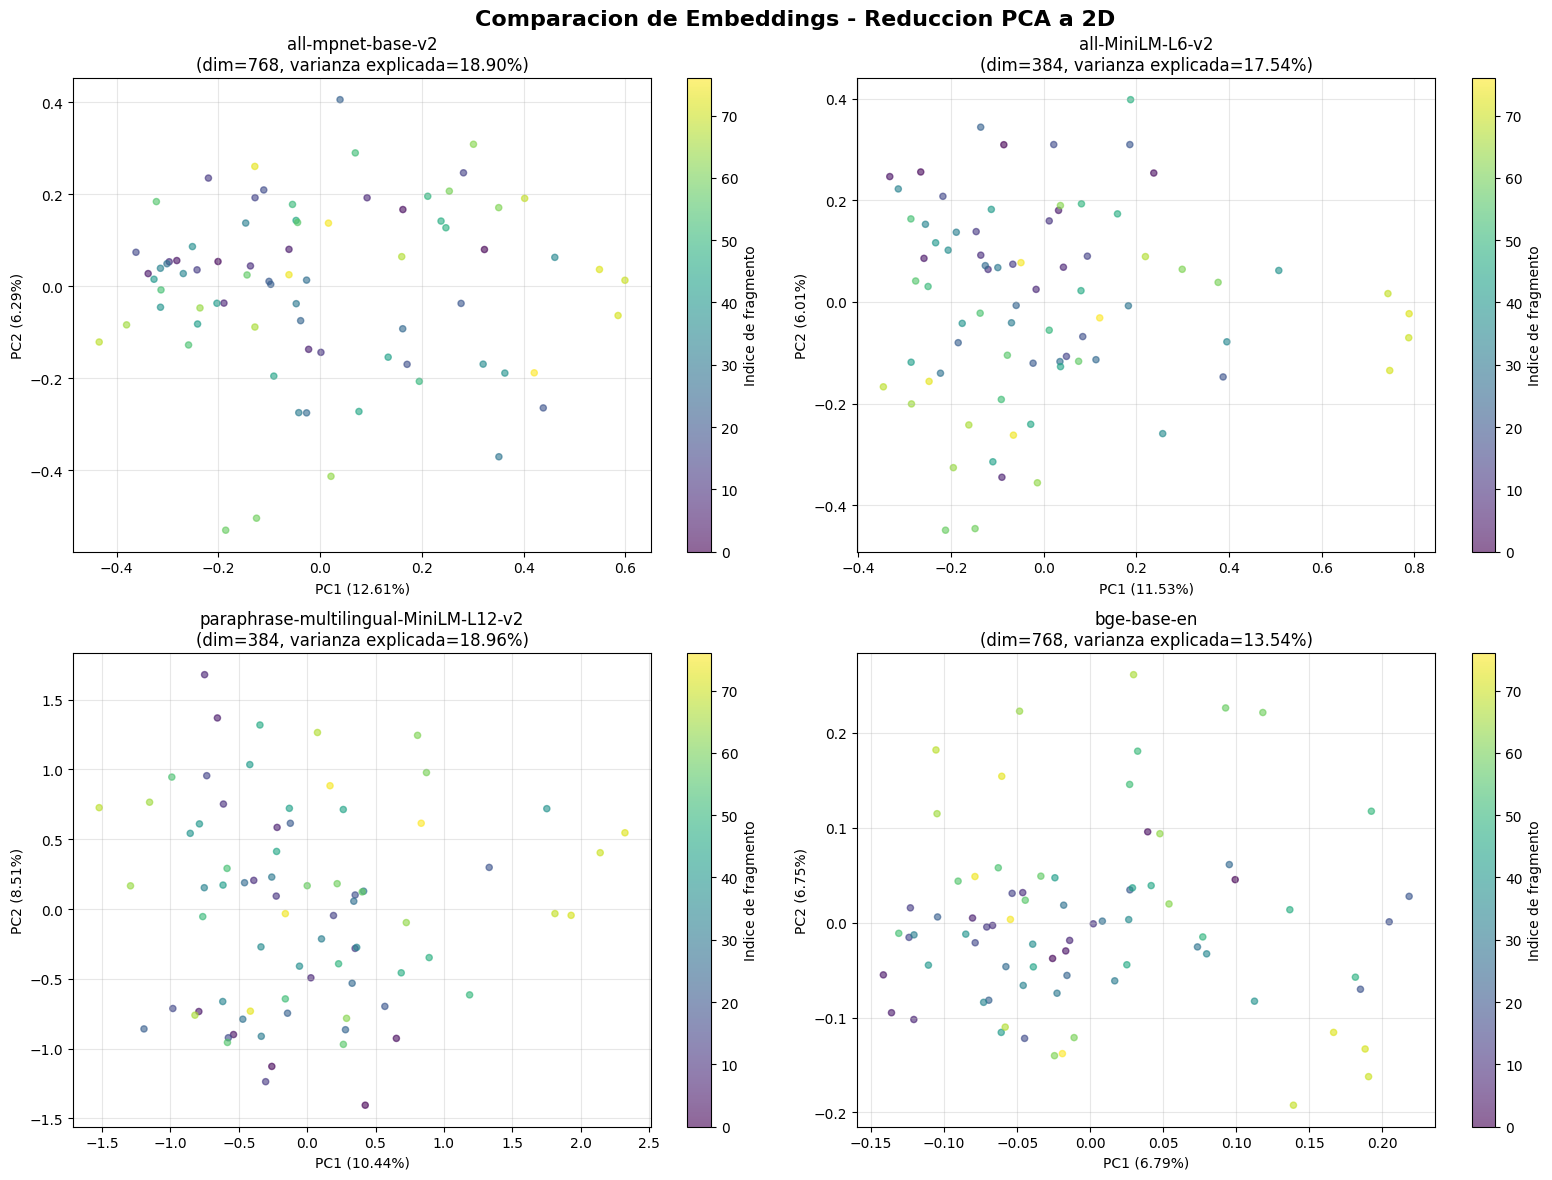


VARIANZA EXPLICADA POR PCA

all-mpnet-base-v2:
  - Dimension original: 768
  - Componentes para 90% varianza: 43
  - Componentes para 95% varianza: 1
  - Varianza PC1: 12.61%
  - Varianza PC2: 6.29%
  - Varianza total 2D: 18.90%

all-MiniLM-L6-v2:
  - Dimension original: 384
  - Componentes para 90% varianza: 44
  - Componentes para 95% varianza: 1
  - Varianza PC1: 11.53%
  - Varianza PC2: 6.01%
  - Varianza total 2D: 17.54%

paraphrase-multilingual-MiniLM-L12-v2:
  - Dimension original: 384
  - Componentes para 90% varianza: 38
  - Componentes para 95% varianza: 49
  - Varianza PC1: 10.44%
  - Varianza PC2: 8.51%
  - Varianza total 2D: 18.96%

all-mpnet-base-v2:
  - Dimension original: 768
  - Componentes para 90% varianza: 43
  - Componentes para 95% varianza: 1
  - Varianza PC1: 12.61%
  - Varianza PC2: 6.29%
  - Varianza total 2D: 18.90%

all-MiniLM-L6-v2:
  - Dimension original: 384
  - Componentes para 90% varianza: 44
  - Componentes para 95% varianza: 1
  - Varianza PC1: 11.5

In [11]:
# Visualizacion comparativa de dimensiones
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparacion de Embeddings - Reduccion PCA a 2D', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (model_key, embeddings) in enumerate(embeddings_by_model.items()):
    # Reducir dimensiones con PCA
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Plotear
    ax = axes[idx]
    scatter = ax.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=range(len(embeddings_2d)),
        cmap='viridis',
        alpha=0.6,
        s=20
    )
    
    ax.set_title(f'{model_key}\n(dim={MODELS_CONFIG[model_key]["embedding_size"]}, varianza explicada={pca.explained_variance_ratio_.sum():.2%})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    plt.colorbar(scatter, ax=ax, label='Indice de fragmento')

plt.tight_layout()
output_path = f"{OUTPUT_DIR}pca_comparison_all_models.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Visualizacion comparativa guardada en: {output_path}")
plt.show()

# Analisis de varianza explicada
print("\n" + "="*80)
print("VARIANZA EXPLICADA POR PCA")
print("="*80)

variance_data = {}
for model_key, embeddings in embeddings_by_model.items():
    pca = PCA(n_components=min(50, embeddings.shape[1]))
    pca.fit(embeddings)
    
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    n_components_90 = np.argmax(cumsum >= 0.90) + 1
    n_components_95 = np.argmax(cumsum >= 0.95) + 1
    
    variance_data[model_key] = {
        'original_dim': embeddings.shape[1],
        'n_components_90': int(n_components_90),
        'n_components_95': int(n_components_95),
        'variance_pc1': float(pca.explained_variance_ratio_[0]),
        'variance_pc2': float(pca.explained_variance_ratio_[1]),
        'variance_2d_total': float(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])
    }
    
    print(f"\n{model_key}:")
    print(f"  - Dimension original: {embeddings.shape[1]}")
    print(f"  - Componentes para 90% varianza: {n_components_90}")
    print(f"  - Componentes para 95% varianza: {n_components_95}")
    print(f"  - Varianza PC1: {pca.explained_variance_ratio_[0]:.2%}")
    print(f"  - Varianza PC2: {pca.explained_variance_ratio_[1]:.2%}")
    print(f"  - Varianza total 2D: {variance_data[model_key]['variance_2d_total']:.2%}")

# Guardar datos de varianza
save_experiment_results(
    2,
    "punto2_pca_variance_analysis",
    variance_data
)

print("\n" + "="*80)
print("Analisis de varianza completado")
print("="*80)

## 2.9 Conclusiones

Resumen de hallazgos del analisis de embeddings de oraciones.

In [12]:
# Generar reporte de conclusiones
print("="*80)
print("RESUMEN Y CONCLUSIONES - PUNTO 2")
print("="*80)

print("\n1. CONFIGURACION DEL EXPERIMENTO:")
print(f"   - Documentos procesados: {len(documents)}")
print(f"   - Fragmentos generados: {len(chunks)}")
print(f"   - Tamano de fragmento: {CHUNK_SIZE} caracteres")
print(f"   - Solapamiento: {CHUNK_OVERLAP} caracteres")
print(f"   - Modelos evaluados: {len(embeddings_by_model)}")

print("\n2. MODELOS UTILIZADOS:")
for model_key, config in MODELS_CONFIG.items():
    print(f"   - {model_key}: {config['embedding_size']} dimensiones")

print("\n3. RENDIMIENTO POR SIMILITUD PROMEDIO:")
for i, (model_key, metrics) in enumerate(sorted_by_avg):
    print(f"   {i+1}. {model_key}: {metrics['avg_similarity']:.4f}")

print("\n4. RENDIMIENTO POR SIMILITUD MAXIMA:")
for i, (model_key, metrics) in enumerate(sorted_by_max):
    print(f"   {i+1}. {model_key}: {metrics['max_similarity']:.4f}")

print("\n5. CONSISTENCIA (MENOR VARIABILIDAD):")
for i, (model_key, metrics) in enumerate(sorted_by_consistency):
    print(f"   {i+1}. {model_key}: {metrics['consistency']:.4f}")

print("\n6. EFICIENCIA DIMENSIONAL (PCA):")
# Verificar que variance_data existe y tiene la estructura correcta
if 'variance_data' in dir() and isinstance(variance_data, dict):
    try:
        # Filtrar las claves que son modelos (excluir timestamp y experiment_name)
        model_variance_data = {k: v for k, v in variance_data.items() 
                              if isinstance(v, dict) and 'variance_2d_total' in v}
        
        if len(model_variance_data) > 0:
            # Ordenar por varianza 2D
            sorted_by_variance = sorted(model_variance_data.items(), 
                                       key=lambda x: x[1]['variance_2d_total'], 
                                       reverse=True)
            for i, (model_key, data) in enumerate(sorted_by_variance):
                print(f"   {i+1}. {model_key}: {data['variance_2d_total']:.2%} varianza en 2D")
        else:
            print("   [No se encontraron datos de varianza válidos]")
    except Exception as e:
        print(f"   [Error procesando variance_data: {str(e)}]")
else:
    print("   [Variable variance_data no existe - ejecutar celda 23]")

print("\n7. ARCHIVOS GENERADOS:")
print(f"   - Embeddings en cache: {CACHE_DIR}")
print(f"   - Visualizaciones PCA: {OUTPUT_DIR}")
print(f"   - Resultados JSON: {RESULTS_DIR}")
print(f"   - Chunks procesados: {CACHE_DIR}")

print("\n" + "="*80)
print("EXPERIMENTO COMPLETADO EXITOSAMENTE")
print("="*80)

# Guardar reporte final
final_report = {
    "timestamp": datetime.now().isoformat(),
    "experiment_name": "punto2_final_report",
    "configuration": {
        "num_documents": len(documents),
        "num_chunks": len(chunks),
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
        "num_models": len(embeddings_by_model)
    },
    "models": {k: {"name": v["name"], "embedding_size": v["embedding_size"]} for k, v in MODELS_CONFIG.items()},
    "rankings": {
        "by_avg_similarity": [(k, float(v['avg_similarity'])) for k, v in sorted_by_avg],
        "by_max_similarity": [(k, float(v['max_similarity'])) for k, v in sorted_by_max],
        "by_consistency": [(k, float(v['consistency'])) for k, v in sorted_by_consistency]
    },
    "global_metrics": global_metrics,
    "output_files": {
        "embeddings_cache": CACHE_DIR,
        "visualizations": OUTPUT_DIR,
        "results": RESULTS_DIR,
        "chunks_cache": CACHE_DIR
    }
}

# Agregar datos de varianza si están disponibles
if 'variance_data' in dir() and isinstance(variance_data, dict):
    try:
        # Filtrar solo los datos de modelos
        model_variance_data = {k: v for k, v in variance_data.items() 
                              if isinstance(v, dict) and 'variance_2d_total' in v}
        
        if len(model_variance_data) > 0:
            final_report["variance_analysis"] = model_variance_data
            sorted_by_variance = sorted(model_variance_data.items(), 
                                       key=lambda x: x[1]['variance_2d_total'], 
                                       reverse=True)
            final_report["rankings"]["by_pca_variance"] = [(k, float(v['variance_2d_total'])) 
                                                           for k, v in sorted_by_variance]
    except:
        pass

save_experiment_results(
    2,
    "punto2_final_report",
    final_report
)

print(f"\nReporte final guardado en: {RESULTS_DIR}punto2_final_report.json")


RESUMEN Y CONCLUSIONES - PUNTO 2

1. CONFIGURACION DEL EXPERIMENTO:
   - Documentos procesados: 30
   - Fragmentos generados: 77
   - Tamano de fragmento: 500 caracteres
   - Solapamiento: 50 caracteres
   - Modelos evaluados: 4

2. MODELOS UTILIZADOS:
   - all-mpnet-base-v2: 768 dimensiones
   - all-MiniLM-L6-v2: 384 dimensiones
   - paraphrase-multilingual-MiniLM-L12-v2: 384 dimensiones
   - bge-base-en: 768 dimensiones

3. RENDIMIENTO POR SIMILITUD PROMEDIO:
   1. bge-base-en: 0.8787
   2. all-mpnet-base-v2: 0.6429
   3. all-MiniLM-L6-v2: 0.6156
   4. paraphrase-multilingual-MiniLM-L12-v2: 0.5754

4. RENDIMIENTO POR SIMILITUD MAXIMA:
   1. bge-base-en: 0.8955
   2. all-mpnet-base-v2: 0.6608
   3. all-MiniLM-L6-v2: 0.6576
   4. paraphrase-multilingual-MiniLM-L12-v2: 0.6325

5. CONSISTENCIA (MENOR VARIABILIDAD):
   1. bge-base-en: 0.9900
   2. all-mpnet-base-v2: 0.9858
   3. all-MiniLM-L6-v2: 0.9713
   4. paraphrase-multilingual-MiniLM-L12-v2: 0.9681

6. EFICIENCIA DIMENSIONAL (PCA):
